In [1]:
try:
    import mat73
except ModuleNotFoundError:
    !pip install mat73
    import mat73

In [2]:
import os
import scipy
from scipy import stats
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def load_mat_file(data_dir, file_url, file_name):
    
    full_path = Path(data_dir) / file_name

    if not full_path.exists():
        full_path.parent.mkdir(parents=True, exist_ok=True)
        tmp = full_path.with_name(full_path.name + ".part")
        !wget "$file_url" -O "$tmp"
        tmp.replace(full_path)  # only runs if wget succeeded

    
    try:
        return mat73.loadmat(file=str(full_path))
    except Exception :
        return scipy.io.loadmat(
            file_name=str(full_path),
            squeeze_me=True,
            chars_as_strings=True,
            struct_as_record=False
        )

In [4]:
DATA_DIR = "/media/naeem_md93/DRIVE/MNAV/EC/amadeus08292019_a.mwk/"

FILES = {
    "meta": "amadeus08292019_a.mat",
    "stim1on": "amadeus08292019_a_neur_tensor_stim1on.mat",
    "gocueon": "amadeus08292019_a_neur_tensor_gocueon.mat",
    "joyon": "amadeus08292019_a_neur_tensor_joyon.mat",
    "joyoff": "amadeus08292019_a_neur_tensor_joyoff.mat",
    "spont": "amadeus08292019_a_neur_tensor_spont.mat",
}

URLS = {
    "meta": "https://www.dropbox.com/scl/fo/nw6zals6ayf0w7vszysbl/h/amadeus08292019_a.mwk/amadeus08292019_a.mat?rlkey=e4c8ee6rr9iv7k218ybym6e1b&dl=0",
    "stim1on": "https://www.dropbox.com/scl/fo/nw6zals6ayf0w7vszysbl/h/amadeus08292019_a.mwk/amadeus08292019_a_neur_tensor_stim1on.mat?rlkey=e4c8ee6rr9iv7k218ybym6e1b&dl=0",
    "gocueon": "https://www.dropbox.com/scl/fo/nw6zals6ayf0w7vszysbl/h/amadeus08292019_a.mwk/amadeus08292019_a_neur_tensor_gocueon.mat?rlkey=e4c8ee6rr9iv7k218ybym6e1b&dl=0",
    "joyon": "https://www.dropbox.com/scl/fo/nw6zals6ayf0w7vszysbl/h/amadeus08292019_a.mwk/amadeus08292019_a_neur_tensor_joyon.mat?rlkey=e4c8ee6rr9iv7k218ybym6e1b&dl=0",
    "joyoff": "https://www.dropbox.com/scl/fo/nw6zals6ayf0w7vszysbl/h/amadeus08292019_a.mwk/amadeus08292019_a_neur_tensor_joyoff.mat?rlkey=e4c8ee6rr9iv7k218ybym6e1b&dl=0",
    "spont": "https://www.dropbox.com/scl/fo/nw6zals6ayf0w7vszysbl/h/amadeus08292019_a.mwk/amadeus08292019_a_neur_tensor_spont.mat?rlkey=e4c8ee6rr9iv7k218ybym6e1b&dl=0",
}

In [5]:
joyon_data = load_mat_file(DATA_DIR, URLS["joyon"], FILES["joyon"])

In [6]:
joyon_data.keys()

dict_keys(['cond_label', 'cond_matrix', 'eyex_tensor_joyon', 'eyey_tensor_joyon', 'hand_tensor_joyon', 'joyon', 'joyon_edges_eyet', 'neur_tensor_joyon', 'pm', 'tensor_structure'])

In [14]:
cond_df = pd.DataFrame(
    data=joyon_data["cond_matrix"],
    columns=joyon_data["cond_label"]
)
cond_df["dist"] = np.abs(cond_df["curr"] - cond_df["target"])
cond_df["dir"] = np.sign(cond_df["ta"])

In [15]:
cond_df

,ta,tp,curr,target,rt,delay,trial_type,seqq,succ,attempt,numrepeat,validtrials_mm,dist,dir
0,-0.65,-0.083334,6.0,5.0,1.045293,485089.871867,3.0,1.0,0.0,2.0,0.0,0.0,1.0,-1.0
1,-0.65,-0.716666,6.0,5.0,1.172976,559749.171158,3.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0
2,1.95,1.500000,3.0,6.0,0.132777,581696.045002,3.0,1.0,0.0,2.0,0.0,1.0,3.0,1.0
3,1.95,1.283333,3.0,6.0,0.354296,982605.107859,3.0,1.0,0.0,2.0,1.0,1.0,3.0,1.0
4,1.95,1.883316,3.0,6.0,0.916982,424875.567801,3.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429,2.60,0.000000,1.0,5.0,2.213367,548256.215556,1.0,2.0,0.0,2.0,12.0,0.0,4.0,1.0
2430,2.60,9.683288,1.0,5.0,19.585713,501940.926054,1.0,2.0,0.0,2.0,13.0,0.0,4.0,1.0
2431,2.60,99.000000,1.0,5.0,0.864288,517101.363983,1.0,2.0,0.0,99.0,14.0,0.0,4.0,1.0
2432,2.60,9.366635,1.0,5.0,1.323893,400059.776842,1.0,2.0,0.0,2.0,15.0,0.0,4.0,1.0


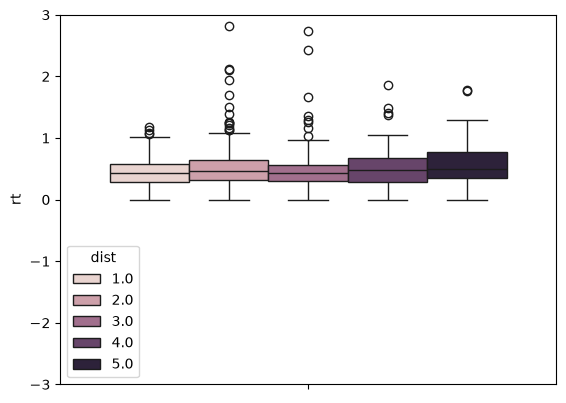

In [22]:
sns.boxplot(
    data=cond_df.loc[
        (cond_df["trial_type"] == 3)
        & (cond_df["attempt"] == 1)
        & (cond_df["succ"] == 1)
        & (cond_df["validtrials_mm"] == 1)
    , :],
    y="rt",
    hue="dist"
)
plt.ylim((-3, 3))
plt.show()